
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [1]:
import numpy as np

from datastructures import *
from training import *
from models import *
from residuals import *

/home/fmoller/miniforge3/envs/pygproj/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load all organoids
data_dir = "training_data"
graphs = load_dir_to_graphs(data_dir)
print(f"Loaded {len(graphs)} organoids.")

# Load metadata & attach
meta = load_aux_metadata_for_dir("training_data")
attached = attach_metadata_to_graphs(graphs, meta)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

Loaded 1215 graphs; skipped 0.
Loaded 1215 organoids.
Attached metadata to 1215/1215 graphs.


In [3]:

# (Optional) global outlier filtering BEFORE split (applies to all)
low_pct, high_pct = 0.0, 100.0   # example: keep middle 0–95th percentile
graphs, thr = filter_outliers(graphs, low_pct=low_pct, high_pct=high_pct, stat="median")
print(f"After global filter: {len(graphs)} organoids | thresholds: {thr}")

After global filter: 1215 organoids | thresholds: {'low': -0.0022743481677025557, 'high': 0.8184399008750916}


In [4]:
# graphs: list[Data] already loaded and with .meta attached
complexities = []
for g in graphs:
    md = getattr(g, "meta", {}) or {}
    v = md.get("complexity", np.nan)
    try:
        v = float(v)
    except Exception:
        v = np.nan
    complexities.append(v)

complexities = np.asarray(complexities, dtype=float)
mask_keep = np.isfinite(complexities) & (complexities >= -1.0)

kept_graphs    = [g for g, m in zip(graphs, mask_keep) if m]
dropped_graphs = [g for g, m in zip(graphs, mask_keep) if not m]

print(f"Complexity filter: kept {len(kept_graphs)} / {len(graphs)} | "
      f"dropped {len(dropped_graphs)} (missing/NaN or < 1)")

# replace your working list
graphs = kept_graphs

Complexity filter: kept 1182 / 1215 | dropped 33 (missing/NaN or < 1)


In [5]:
# Split dataset by organoid
g_train, g_val = split_graphs(graphs, val_frac=0.1, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")


center, scale = standardize_targets(g_train, g_val, robust=True)

Split -> train: 1064 | val: 118


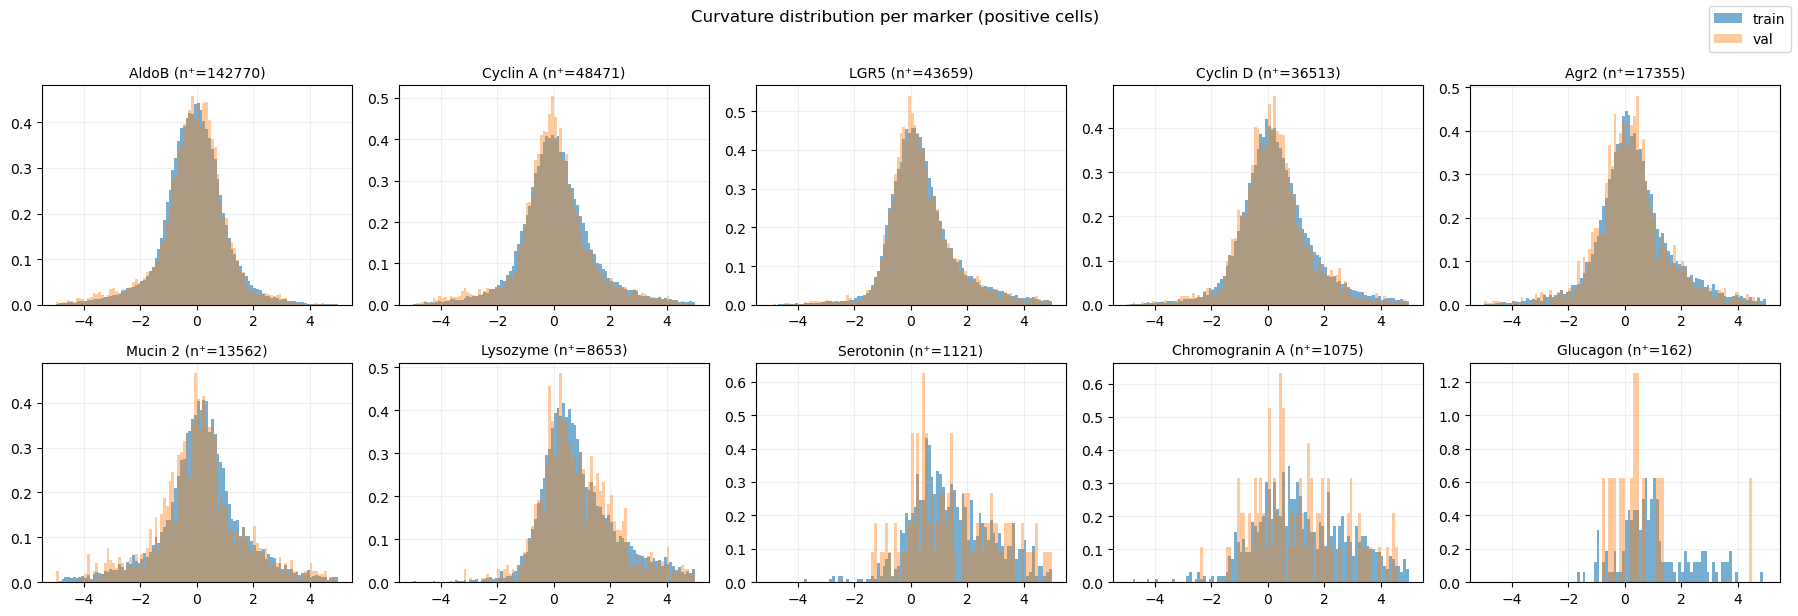

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from datastructures import load_marker_names_from_dir

# --- Collect X and y from train/val ---
X_train = np.vstack([g.x.cpu().numpy() for g in g_train])
y_train = np.concatenate([g.y.cpu().numpy() for g in g_train])
X_val   = np.vstack([g.x.cpu().numpy() for g in g_val])
y_val   = np.concatenate([g.y.cpu().numpy() for g in g_val])

M = X_train.shape[1]

# --- Marker names ---
marker_names = load_marker_names_from_dir("training_data")
if marker_names is None:
    marker_names = [f"m{j}" for j in range(M)]
else:
    marker_names = list(marker_names) + [f"m{j}" for j in range(len(marker_names), M)]

# --- Identify positives and rank markers by prevalence ---
pos_train = X_train > 0.5
n_pos = pos_train.sum(axis=0)
order = np.argsort(-n_pos)
marker_idx_show = order[:min(12, M)]          # show up to 12 markers
marker_names_sel = [marker_names[m] for m in marker_idx_show]

# --- Curvature values for positives ---
curv_train = [y_train[pos_train[:, m]] for m in marker_idx_show]
curv_val   = [y_val[(X_val > 0.5)[:, m]] for m in marker_idx_show]

# --- Histogram binning ---
edges = np.linspace(-5, 5, 101)
# --- Plot ---
cols = 5
rows = int(np.ceil(len(marker_idx_show) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.6, rows * 3.0), squeeze=False)
axes = axes.ravel()

for i, m in enumerate(marker_idx_show):
    ax = axes[i]
    ax.hist(curv_train[i], bins=edges, density=True, alpha=0.6, label="train")
    ax.hist(curv_val[i],   bins=edges, density=True, alpha=0.4, label="val")
    ax.set_title(f"{marker_names_sel[i]} (n⁺={n_pos[m]})", fontsize=10)
    ax.grid(alpha=0.2)

# hide unused axes
for j in range(len(marker_idx_show), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Curvature distribution per marker (positive cells)", y=1.02)

plt.tight_layout()
plt.show()


In [ ]:
num_layers = 3
# num_hops   = num_layers
# ego_train  = build_ego_dataset(
#     g_train,
#     num_hops=num_hops,
#     max_centers_per_graph=None,  # e.g. 80 random centers per organoid
#     seed=0,
# )


In [21]:

# Build the model
n_markers = int(g_train[0].x.size(1))
model = PureSAGECurvature(
    n_markers=n_markers,
    hidden_dim=64,
    num_layers=num_layers,
    dropout=0.1,      
    residual=True,
    norm='batch'      
)



cfg = TrainConfig(
    lr=1e-3,          
    batch_size=128,
    max_epochs=100,   
    patience=30,
    huber_delta=1.0,
    lambda_calib=0,     
    calib_mode="corr",
    num_workers=4, 
)


AssertionError: num_layers must be >= 1

In [ ]:

model, metrics, history = train(model, g_train, g_val, cfg)

# # from training import train_lbfgs
# model, metrics, history = train_lbfgs(
#     model, g_train, g_val, cfg,
#     outer_steps=50,   # try 30–80
#     lr=0.5,           # try 0.2–1.0
#     max_iter=20,      # internal line-search iterations
#     history_size=100
# )
# print("Best val MAE:", metrics["val_mae"])


epoch 001 | train loss 1.0772 mae 0.9912 | val loss 0.9552 mae 0.9645
epoch 002 | train loss 0.8883 mae 0.9777 | val loss 0.8986 mae 0.9630
epoch 003 | train loss 0.8315 mae 0.9685 | val loss 0.8549 mae 0.9607
epoch 004 | train loss 0.8122 mae 0.9626 | val loss 0.8307 mae 0.9583
epoch 005 | train loss 0.8037 mae 0.9585 | val loss 0.8172 mae 0.9565
epoch 006 | train loss 0.7965 mae 0.9557 | val loss 0.8086 mae 0.9552
epoch 007 | train loss 0.7915 mae 0.9532 | val loss 0.8032 mae 0.9540
epoch 008 | train loss 0.7873 mae 0.9517 | val loss 0.7988 mae 0.9517
epoch 009 | train loss 0.7843 mae 0.9492 | val loss 0.7945 mae 0.9490
epoch 010 | train loss 0.7831 mae 0.9482 | val loss 0.7918 mae 0.9501
epoch 011 | train loss 0.7804 mae 0.9475 | val loss 0.7908 mae 0.9496
epoch 012 | train loss 0.7776 mae 0.9457 | val loss 0.7875 mae 0.9461
epoch 013 | train loss 0.7770 mae 0.9437 | val loss 0.7853 mae 0.9456
epoch 014 | train loss 0.7754 mae 0.9435 | val loss 0.7847 mae 0.9456
epoch 015 | train lo

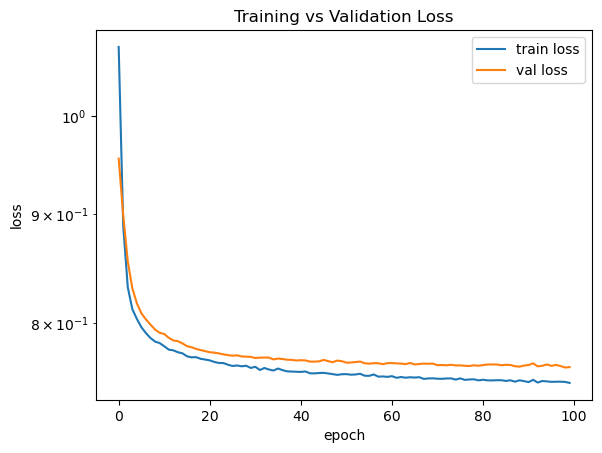

In [ ]:
import json, os
import matplotlib.pyplot as plt

def _load_history_fallback():
    path = "artifacts/history.json"
    if os.path.exists(path):
        with open(path, "r") as f:
            return json.load(f)
    return None

# Use in-memory 'history' if present; else load from disk
try:
    _hist = history
except NameError:
    _hist = _load_history_fallback()

if _hist is None:
    print("No history found. Define a `history` dict or save it to artifacts/history.json.")
else:
    # Loss
    plt.figure()
    plt.plot(_hist.get("train_loss", []), label="train loss")
    plt.plot(_hist.get("val_loss", []), label="val loss")
    plt.yscale('log')
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training vs Validation Loss")
    plt.legend(); plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from analysis_basic_gaussian import *

device = cfg.device if 'cfg' in globals() else ('cuda' if torch.cuda.is_available() else 'cpu')
marker_names = load_marker_names_from_dir(data_dir)

# === Inference on VALIDATION ===
y, mu, log_var, X = run_inference(g_val, model, device=device, return_log_var=True)

# transform back (if you trained on standardized targets)
y  = y  * scale + center
mu = mu * scale + center

# log_var rescales as: log_var_phys = log_var_std + 2*log(scale)
log_var = log_var + 2.0 * np.log(scale)
var = np.exp(log_var)

# Residuals per marker (positives only) using mean prediction
residuals_model, residuals_base, n_pos, mu_pos = residuals_per_marker(y, mu, X)


nll_model, nll_base, Delta_mean, Delta_var, _ = nll_per_marker(y, mu, log_var, X)



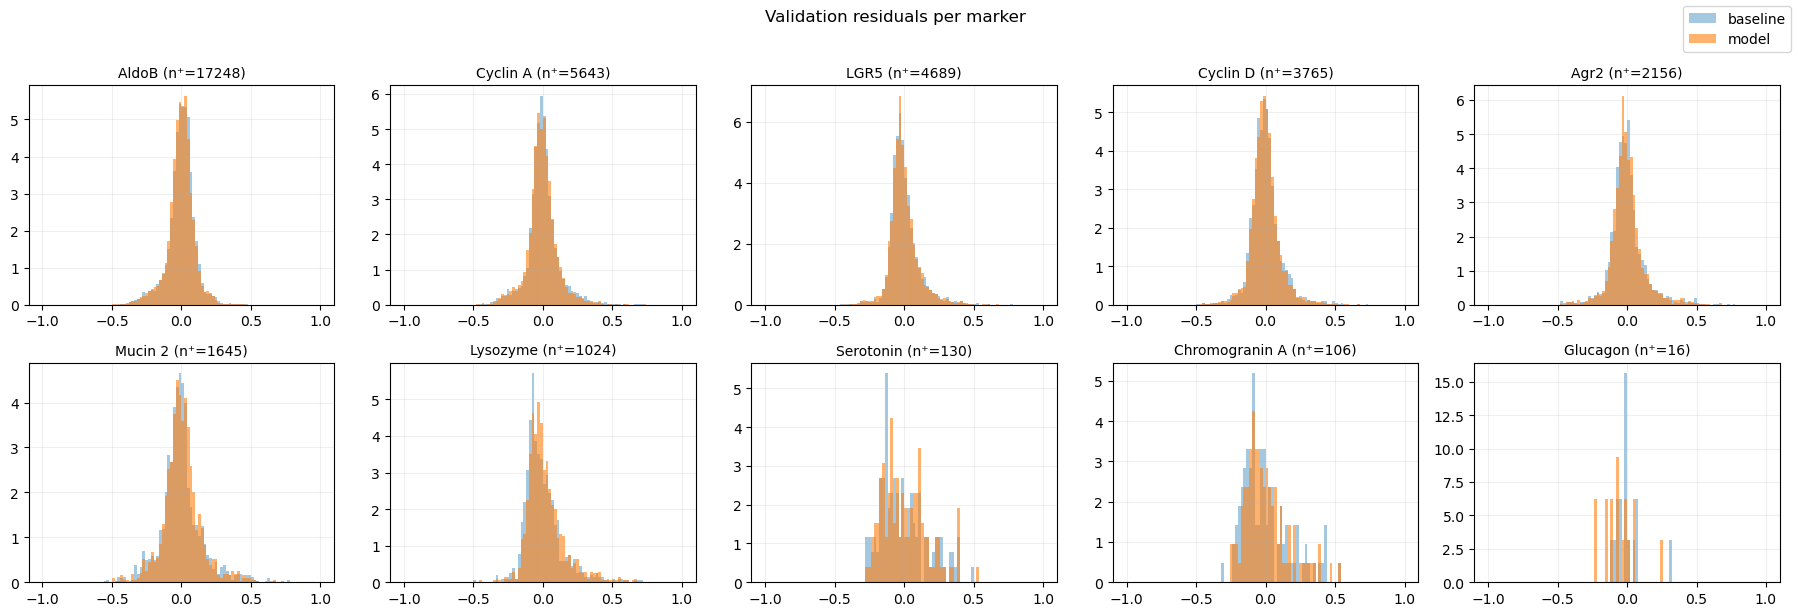

In [ ]:
# Helper: pick top markers by positives for display
order_by_n = np.argsort(-n_pos)
marker_idx_show = order_by_n[:min(12, (X.shape[1] if X.ndim == 2 else 12))]
marker_names_sel = [marker_names[m] if m < len(marker_names) else f"m{m}" for m in marker_idx_show]

# === Histograms of residuals per marker (model vs baseline) ===
cols = 5; rows = int(np.ceil(len(marker_idx_show)/cols)) if len(marker_idx_show) else 1
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.6, rows*3.0), squeeze=False)
axes = axes.ravel()
edges = np.linspace(-1.0, 1.0, 101)  # symmetric bins

for k, m in enumerate(marker_idx_show):
    ax = axes[k]
    rb = residuals_base[m]; rm = residuals_model[m]
    if rb.size == 0:
        ax.axis('off'); continue
    ax.hist(rb, bins=edges, density=True, alpha=0.4, label="baseline")
    ax.hist(rm, bins=edges, density=True, alpha=0.6, label="model")
    ax.set_title(f"{marker_names_sel[k]} (n⁺={n_pos[m]})", fontsize=10)
    ax.grid(True, alpha=0.2)

for k in range(len(marker_idx_show), len(axes)):
    axes[k].axis('off')
if len(marker_idx_show):
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
fig.suptitle("Validation residuals per marker", y=1.02)
plt.tight_layout(); plt.show()


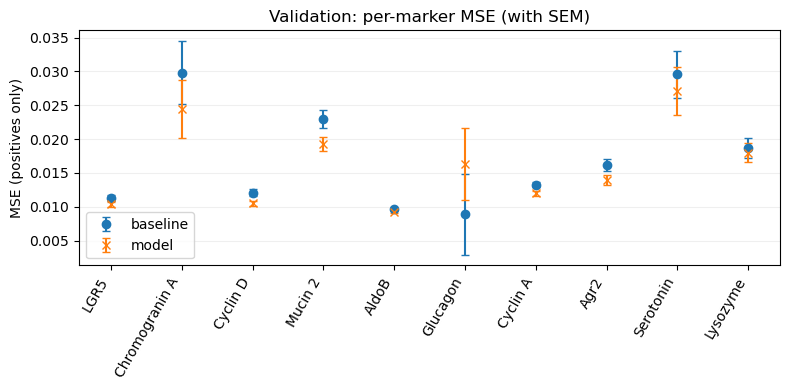

In [ ]:
# MSE and SEM (SEM over squared residuals)
mse_model = np.array([np.mean(r**2) for r in residuals_model])
mse_base  = np.array([np.mean(r**2) for r in residuals_base])
sem_model = np.array([np.std((r**2), ddof=1)/np.sqrt(r.size) for r in residuals_model])
sem_base  = np.array([np.std((r**2), ddof=1)/np.sqrt(r.size) for r in residuals_base])

x = np.arange(len(marker_names))

plt.figure(figsize=(max(8, 0.5*len(marker_names)), 4))
plt.errorbar(x, mse_base,  yerr=sem_base,  fmt='o', capsize=3, label="baseline")
plt.errorbar(x, mse_model, yerr=sem_model, fmt='x', capsize=3, label="model")
plt.xticks(x, marker_names, rotation=60, ha='right')
plt.ylabel("MSE (positives only)")
plt.title("Validation: per-marker MSE (with SEM)")
plt.grid(True, axis='y', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


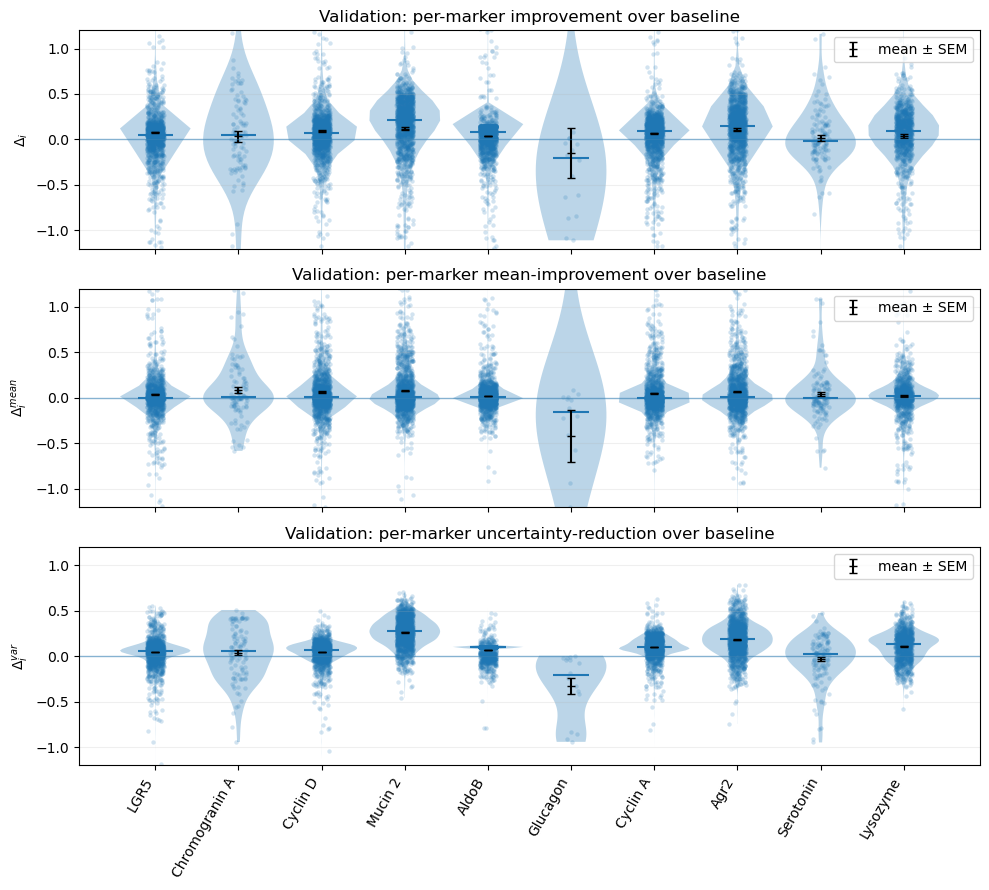

In [ ]:
deltas = [(nll_b - nll_m) for nll_b, nll_m in zip(nll_base, nll_model)]

x = np.arange(len(marker_names))
rng = np.random.default_rng(0)

fig, axes = plt.subplots(
    3, 1,
    figsize=(max(10, 0.5*len(marker_names)), 9),
    sharex=True
)

panels = [
    (deltas,      r"$\Delta_i$",      "Validation: per-marker improvement over baseline"),
    (Delta_mean,  r"$\Delta_{i}^{mean}$",  "Validation: per-marker mean-improvement over baseline"),
    (Delta_var,   r"$\Delta_{i}^{var}$", "Validation: per-marker uncertainty-reduction over baseline"),
]

for ax, (D, ylab, title) in zip(axes, panels):
    # --- Violin plot ---
    vp = ax.violinplot(
        D,
        positions=x,
        widths=0.85,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    for body in vp['bodies']:
        body.set_alpha(0.3)

    # --- Scatter overlay (jittered, default blue) ---
    for i, d in enumerate(D):
        d = np.asarray(d)
        if d.size == 0:
            continue
        if d.size > 1500:
            idx = rng.choice(d.size, size=1500, replace=False)
            d_plot = d[idx]
        else:
            d_plot = d

        jitter = rng.uniform(-0.1, 0.1, size=d_plot.size)
        ax.scatter(
            np.full(d_plot.size, x[i]) + jitter,
            d_plot,
            s=10,
            alpha=0.2,
            linewidths=0,
            color='C0',   # default blue
        )

    # --- Mean ± SEM overlay ---
    D_mean = np.array([np.mean(np.asarray(d)) if np.asarray(d).size else np.nan for d in D], dtype=float)
    D_sem  = np.array([np.std(np.asarray(d), ddof=1)/np.sqrt(np.asarray(d).size) if np.asarray(d).size > 1 else np.nan
                       for d in D], dtype=float)
    ax.errorbar(x, D_mean, yerr=D_sem, fmt='k_', capsize=3, label="mean ± SEM")

    # Reference line: no improvement
    ax.axhline(0, linewidth=1, alpha=0.5)

    ax.set_ylim([-1.2, 1.2])

    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.2)
    ax.legend(loc="upper right")

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(marker_names, rotation=60, ha='right')

plt.tight_layout()
plt.show()


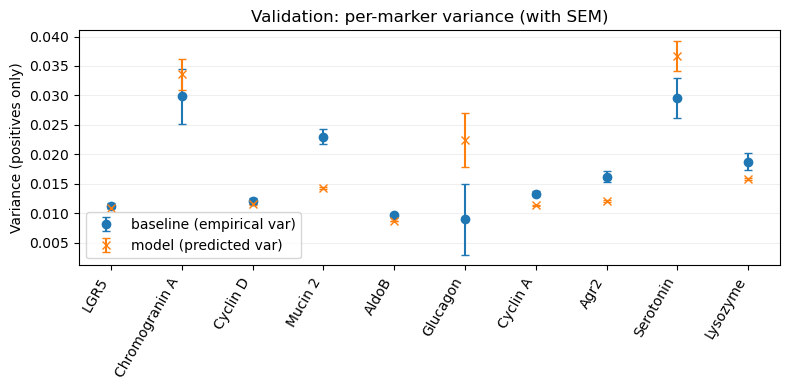

In [ ]:
# --- Predicted variance per marker (positives only), with SEM ---

# X is (N, M) marker matrix (binarized or thresholded)
# var is (N,) predicted variance in physical units (after rescaling log_var)

Xb = (X > 0.5)  # boolean positives

# Model: mean predicted variance per marker among positives
var_model = np.array([np.mean(var[Xb[:, m]]) for m in range(X.shape[1])])
sem_var_model = np.array([np.std(var[Xb[:, m]], ddof=1) / np.sqrt(np.sum(Xb[:, m]))
                          for m in range(X.shape[1])])

# Baseline: empirical residual variance (same as your MSE baseline)
# (positives only, already computed as mse_base + sem_base in your code)
var_base = mse_base
sem_var_base = sem_base

x = np.arange(len(marker_names))

plt.figure(figsize=(max(8, 0.5*len(marker_names)), 4))
plt.errorbar(x, var_base,     yerr=sem_var_base,     fmt='o', capsize=3, label="baseline (empirical var)")
plt.errorbar(x, var_model,    yerr=sem_var_model,    fmt='x', capsize=3, label="model (predicted var)")
plt.xticks(x, marker_names, rotation=60, ha='right')
plt.ylabel("Variance (positives only)")
plt.title("Validation: per-marker variance (with SEM)")
plt.grid(True, axis='y', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import copy
import numpy as np
import torch
from torch_geometric.loader import DataLoader


# TODO: Implement marker exclusivity on flip


# -----------------------------
# Helper: predict (mu, logvar) for center node of each subgraph in a list
# -----------------------------
@torch.no_grad()
def predict_center_mu_logvar(subgraphs, model, device=None, batch_size=64, num_workers=0, pin_memory=True):
    """
    Inputs:
      subgraphs : list of torch_geometric.data.Data
                 each must have .x, .edge_index, and .center_idx (int)
      model     : GNN model; forward returns (mu, logvar) with shape (num_nodes, 1) or (num_nodes,)
      device    : 'cuda'/'cpu' (optional)

    Outputs:
      mu_c      : np.ndarray, shape (B,), predicted mean at center node for each subgraph
      lv_c      : np.ndarray, shape (B,), predicted log-variance at center node for each subgraph
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device).eval()
    loader = DataLoader(subgraphs, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=pin_memory)

    mu_centers = []
    lv_centers = []

    for batch in loader:
        batch = batch.to(device, non_blocking=True)

        (mu, logvar), _ = model(batch.x, batch.edge_index)

        # Ensure shape (num_nodes,)
        mu = mu.view(-1)
        logvar = logvar.view(-1)

        # DataLoader concatenates graphs; need center indices with graph offsets
        # PyG provides batch.batch (node->graph id) and batch.ptr (graph start pointers)
        ptr = batch.ptr  # shape (num_graphs+1,)
        # For each graph i, center node in the batch is ptr[i] + center_idx_of_graph_i
        centers = []
        for i in range(batch.num_graphs):
            c = int(batch.center_idx[i].item()) if torch.is_tensor(batch.center_idx[i]) else int(batch.center_idx[i])
            centers.append(ptr[i].item() + c)
        centers = torch.tensor(centers, device=device, dtype=torch.long)

        mu_centers.append(mu[centers].detach().cpu().numpy())
        lv_centers.append(logvar[centers].detach().cpu().numpy())

    mu_c = np.concatenate(mu_centers, axis=0).astype(np.float64)
    lv_c = np.concatenate(lv_centers, axis=0).astype(np.float64)
    return mu_c, lv_c


# -----------------------------
# Helper: compute hop rings (nodes at exact hop distance) in a subgraph
# -----------------------------
def hop_rings(edge_index, center_idx, max_hops):
    """
    Inputs:
      edge_index  : torch.LongTensor shape (2, E)
      center_idx  : int, center node index in this subgraph
      max_hops    : int

    Outputs:
      rings       : list of lists; rings[h] = list of node indices at exact hop distance h
                   includes rings[0] = [center_idx]
    """
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()

    # Treat as undirected for "neighborhood" (common in tissue adjacency)
    adj = {}
    for u, v in zip(src, dst):
        adj.setdefault(u, set()).add(v)
        adj.setdefault(v, set()).add(u)

    visited = set([center_idx])
    frontier = set([center_idx])
    rings = [[center_idx]]

    for h in range(1, max_hops + 1):
        nxt = set()
        for u in frontier:
            for v in adj.get(u, ()):
                if v not in visited:
                    nxt.add(v)
        rings.append(sorted(nxt))
        visited |= nxt
        frontier = nxt
        if len(frontier) == 0:
            # pad remaining hops with empty rings
            for _ in range(h + 1, max_hops + 1):
                rings.append([])
            break

    return rings


# -----------------------------
# Core: build perturbed copies and aggregate delta(mu) and delta(logvar)
# -----------------------------
def perturbation_influence_maps(
    subgraphs,               # list[Data]: ego-subgraphs; each must have .center_idx and x[:, M] binary markers
    model,                   # torch.nn.Module: trained GNN; forward(x, edge_index) -> (mu, logvar) for all nodes
    marker_names,            # list[str]: length M; names of marker columns in x
    k_hops,                  # int: analyze hop rings 1..k_hops around the center node
    perturb="zero",          # str: "zero" sets marker->0 on selected nodes; "flip" sets marker->1-x
    max_subgraphs=200,       # int|None: subsample subgraphs for speed (None = use all)
    device=None,             # str|None: "cuda" / "cpu"; if None chooses automatically
    batch_size=64,           # int: DataLoader batch size for inference on perturbed graphs
):
    """
    Performs node-centered perturbation attribution on ego-subgraphs to quantify how marker composition
    in each hop-ring affects the *center node's* predicted curvature distribution.

    For each subgraph and each hop h=1..k_hops:
      - selects the nodes exactly h hops from the center node
      - for each marker X (feature column), perturbs that marker on those nodes (zero or flip)
      - runs the model and measures the change in the center node prediction:
            Δμ  = μ_perturbed - μ_base
            Δlv = logvar_perturbed - logvar_base
      - accumulates these deltas as (a) overall averages across all centers (total),
        and (b) averages conditioned on the *center node’s* marker(s) Y.

    Normalization:
      - your current implementation normalizes by the number of perturbed positives (n_pert) per case,
        so effects are reported “per perturbed positive” rather than “per subgraph”.

    Returns
    -------
    result : dict with keys

      Total (center type NOT resolved):
        - "delta_mu_total"        : (H, M) mean Δμ per perturbed positive
        - "delta_mu_abs_total"    : (H, M) mean |Δμ| per perturbed positive
        - "delta_lv_total"        : (H, M) mean Δlogvar per perturbed positive
        - "delta_lv_abs_total"    : (H, M) mean |Δlogvar| per perturbed positive
        - "counts_total"          : (H, M) total # perturbed positives accumulated (denominator)

      Center-type resolved (center marker Y resolved):
        - "delta_mu_cmarker"      : (H, M_center, M_pert) mean Δμ for centers with marker Y
        - "delta_mu_abs_cmarker"  : (H, M_center, M_pert) mean |Δμ| for centers with marker Y
        - "delta_lv_cmarker"      : (H, M_center, M_pert) mean Δlogvar for centers with marker Y
        - "delta_lv_abs_cmarker"  : (H, M_center, M_pert) mean |Δlogvar| for centers with marker Y
        - "counts_cmarker"        : (H, M_center, M_pert) total # perturbed positives accumulated

      Metadata:
        - "hops"                  : list[int] hop indices used (length H)
        - "marker_names"          : list[str] marker names (length M)
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Subsample for speed
    if max_subgraphs is not None and len(subgraphs) > max_subgraphs:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(subgraphs), size=max_subgraphs, replace=False)
        subs = [subgraphs[int(i)] for i in idx]
    else:
        subs = list(subgraphs)

    M = len(marker_names)
    hops = list(range(1, k_hops + 1))
    H = len(hops)
    S = len(subgraphs)

    # Baseline predictions for each subgraph center
    base_mu, base_lv = predict_center_mu_logvar(subs, model, device=device, batch_size=batch_size)

    # Center marker matrix for conditioning: (S, M)
    center_X = np.zeros((S, M), dtype=np.int8)
    for si, g in enumerate(subgraphs):
        c = int(g.center_idx)
        center_X[si, :] = g.x[c].detach().cpu().numpy().astype(np.int8)

    # Build all perturbed graphs in one big list for efficient batching
    perturbed = []
    meta = []  # (subgraph_index, hop_index_in_hops_list, marker_index)

    for si, g in enumerate(subs):
        c = int(g.center_idx)
        rings = hop_rings(g.edge_index, c, k_hops)

        for hi, hop in enumerate(hops):
            nodes = rings[hop]
            if len(nodes) == 0:
                continue

            for mi in range(M):
                gp = copy.deepcopy(g)
                x = gp.x

                if perturb == "zero":
                    n_pert = (x[nodes, mi] > 0.5).sum().item() # only perturbs positives
                    x[nodes, mi] = 0
                elif perturb == "flip":
                    n_pert = len(nodes) # perturbs all
                    x[nodes, mi] = 1 - x[nodes, mi]
                else:
                    raise ValueError("perturb must be 'zero' or 'flip'")

                gp.x = x
                perturbed.append(gp)
                meta.append((si, hi, mi, int(n_pert)))

       
    # Predictions on perturbed graphs
    pert_mu, pert_lv = predict_center_mu_logvar(perturbed, model, device=device, batch_size=batch_size)

    # Aggregate deltas by (hop, marker)
    delta_mu_total = np.zeros((H, M), dtype=np.float64)
    delta_mu_abs_total = np.zeros((H, M), dtype=np.float64)
    delta_lv_total = np.zeros((H, M), dtype=np.float64)
    delta_lv_abs_total = np.zeros((H, M), dtype=np.float64)
    
    delta_mu_cmarker = np.zeros((H, M, M), dtype=np.float64)
    delta_mu_abs_cmarker = np.zeros((H, M, M), dtype=np.float64)
    delta_lv_cmarker = np.zeros((H, M, M), dtype=np.float64)
    delta_lv_abs_cmarker = np.zeros((H, M, M), dtype=np.float64)
    
    counts_total = np.zeros((H, M), dtype=np.int64)
    counts_cmarker = np.zeros((H, M, M), dtype=np.int64)
    
    for j, (si, hi, mi, n_pert) in enumerate(meta):
        dmu = pert_mu[j] - base_mu[si]
        dlv = pert_lv[j] - base_lv[si]

        delta_mu_total[hi, mi] += dmu
        delta_mu_abs_total[hi, mi] += abs(dmu)
        delta_lv_total[hi, mi] += dlv
        delta_lv_abs_total[hi, mi] += abs(dlv)        
        counts_total[hi, mi] += n_pert # normalize by how many cells perturbed

         # Condition on center marker(s) Y
         # Total would be the sum over center marker IF markers were exclusive
        ys = np.where(center_X[si, :] == 1)[0]
        for y in ys:
            delta_mu_cmarker[hi, y, mi] += dmu
            delta_mu_abs_cmarker[hi, y, mi] += abs(dmu)
            delta_lv_cmarker[hi, y, mi] += dlv
            delta_lv_abs_cmarker[hi, y, mi] += abs(dlv)
            counts_cmarker[hi, y, mi] += n_pert


    # Normalize
    mask_t = counts_total > 0
    delta_mu_total[mask_t] /= counts_total[mask_t]
    delta_mu_abs_total[mask_t] /= counts_total[mask_t]
    delta_lv_total[mask_t] /= counts_total[mask_t]
    delta_lv_abs_total[mask_t] /= counts_total[mask_t]

    mask_c = counts_cmarker > 0
    delta_mu_cmarker[mask_c] /= counts_cmarker[mask_c]
    delta_mu_abs_cmarker[mask_c] /= counts_cmarker[mask_c]
    delta_lv_cmarker[mask_c] /= counts_cmarker[mask_c]
    delta_lv_abs_cmarker[mask_c] /= counts_cmarker[mask_c]

    return {
        "delta_mu_total": delta_mu_total,
        "delta_mu_abs_total": delta_mu_abs_total,
        "delta_lv_total": delta_lv_total,
        "delta_lv_abs_total": delta_lv_abs_total,
        "counts_total": counts_total,
        "delta_mu_cmarker": delta_mu_cmarker,
        "delta_mu_abs_cmarker": delta_mu_abs_cmarker,
        "delta_lv_cmarker": delta_lv_cmarker,
        "delta_lv_abs_cmarker": delta_lv_abs_cmarker,
        "counts_cmarker": counts_cmarker,
        "hops": hops,
        "marker_names": marker_names,
    }


# -----------------------------
# Quick plotting helpers
# -----------------------------
def plot_influence_heatmap(mat, hops, marker_names, title):
    """
    Inputs:
      mat          : np.ndarray (H, M)
      hops         : list[int]
      marker_names : list[str]
      title        : str

    Output:
      matplotlib heatmap
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(0.7 * len(marker_names) + 3, 0.7 * len(hops) + 2))
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    plt.yticks(range(len(hops)), [f"hop {h}" for h in hops])
    plt.xticks(range(len(marker_names)), marker_names, rotation=60, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_influence_center_resolved(
    mat,
    hops,
    marker_names,
    title,
    center_zero=False,
    sort_center=True,
    cmap="viridis",        # <-- NEW
):
    """
    Inputs:
      mat          : np.ndarray (H, M_center, M_pert)
      hops         : list[int]
      marker_names : list[str]
      title        : str
      center_zero  : bool
      sort_center  : bool
      cmap         : str or matplotlib colormap
    """
    import numpy as np
    import matplotlib.pyplot as plt

    mat = np.asarray(mat)
    H, My, Mx = mat.shape
    assert H == len(hops)
    assert My == len(marker_names)
    assert Mx == len(marker_names)

    # Sort center markers globally (shared across hops)
    order = np.arange(My)
    if sort_center:
        score = np.nanmean(np.abs(mat), axis=(0, 2))  # (My,)
        order = np.argsort(-score)

    mat_s = mat[:, order, :]
    center_names = [marker_names[i] for i in order]

    fig, axes = plt.subplots(
        1, H,
        figsize=(0.50 * len(marker_names) * H + 2.5,
                 0.35 * len(marker_names) + 2),
        squeeze=False
    )
    axes = axes[0]

    for hi, hop in enumerate(hops):
        ax = axes[hi]
        data = mat_s[hi]

        if center_zero:
            vmax = np.nanmax(np.abs(data))
            vmin = -vmax
            im = ax.imshow(
                data,
                aspect="auto",
                vmin=vmin,
                vmax=vmax,
                cmap=cmap,      # <-- USED HERE
            )
        else:
            im = ax.imshow(
                data,
                aspect="auto",
                cmap=cmap,      # <-- AND HERE
            )

        ax.set_xlabel("perturbation marker X", fontsize=13)
        ax.set_ylabel("center marker Y", fontsize=13)

        ax.set_xticks(range(len(marker_names)))
        ax.set_xticklabels(marker_names, rotation=60, ha="right", fontsize=11)
        ax.set_yticks(range(len(center_names)))
        ax.set_yticklabels(center_names, fontsize=11)

        ax.set_title(f"hop {hop}", fontsize=14)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=11)

    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()


## Neighborhood Perturbation Analysis

### What this analysis does

We quantify how **local cell-type composition** influences predicted organoid surface curvature by performing **controlled perturbations** on ego-subgraphs centered at individual cells.

For each ego-subgraph and each hop distance $h = 1,\dots,k$:

1. We identify all cells exactly $h$ hops away from the center cell.
2. For each marker $X$, we perturb that marker on the hop-$h$ neighborhood
   (typically by setting all $X^+$ cells in that ring to $X = 0$).
3. We re-run the trained GNN and record how the **center cell’s predicted curvature**
   changes relative to the unperturbed prediction.

The analysis is repeated across many ego-subgraphs and aggregated:
- **Globally**, averaging over all center cells.
- **Conditioned on center cell type**, i.e. separately for center cells positive for marker $Y$.

All reported effects are normalized by the number of perturbed marker-positive cells,
so values should be interpreted as **effects per perturbed positive** rather than per subgraph.

---

### What is measured

For each perturbation we measure changes in the predicted Gaussian output at the center cell:

- $\Delta \mu = \mu_{\text{perturbed}} - \mu_{\text{original}}$
- $\Delta \log \sigma^2 = \log \sigma^2_{\text{perturbed}} - \log \sigma^2_{\text{original}}$

---

### Interpretation of $\Delta \mu$

- **Positive $\Delta \mu$**  
  Removing marker $X$ from the neighborhood causes the model to predict **higher curvature**
  at the center cell.  
  → The presence of marker $X$ normally *suppresses* curvature.

- **Negative $\Delta \mu$**  
  Removing marker $X$ causes the model to predict **lower curvature**.  
  → The presence of marker $X$ normally *promotes* curvature.

Thus, $\Delta \mu$ captures the **directional influence** of neighborhood cell types on
local tissue bending.

---

### Interpretation of $\Delta \log \sigma^2$

- **Positive $\Delta \log \sigma^2$**  
  Removing marker $X$ makes the model **more uncertain** about the center cell’s curvature.  
  → Marker $X$ provides stabilizing or disambiguating information.

- **Negative $\Delta \log \sigma^2$**  
  Removing marker $X$ makes the model **more confident** in its curvature prediction.  
  → Marker $X$ contributes to variability or ambiguity in curvature outcomes.

Thus, $\Delta \log \sigma^2$ reflects how neighborhood composition affects
**predictive uncertainty**, not just the mean shape.

---

### What the figures show

Each figure consists of one heatmap per hop distance:

- **Columns (X-axis)**: perturbed neighborhood markers $X$
- **Rows (Y-axis)**: center cell markers $Y$
- **Color**: average $\Delta \mu$ or $\Delta \log \sigma^2$ per perturbed positive

Each heatmap answers the question:

> *“Given that the center cell is $Y^+$, how does removing marker $X$ from its
> hop-$h$ neighborhood affect the predicted curvature (or uncertainty) at the center?”*

These maps reveal:
- cell-type–specific interaction ranges,
- which neighborhood signals actively drive curvature,
- and which signals primarily stabilize or destabilize morphological outcomes.


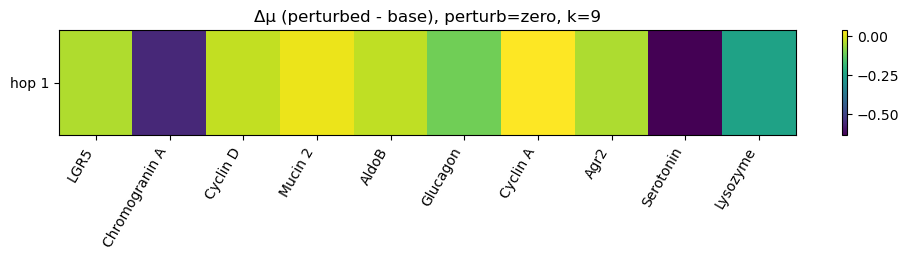

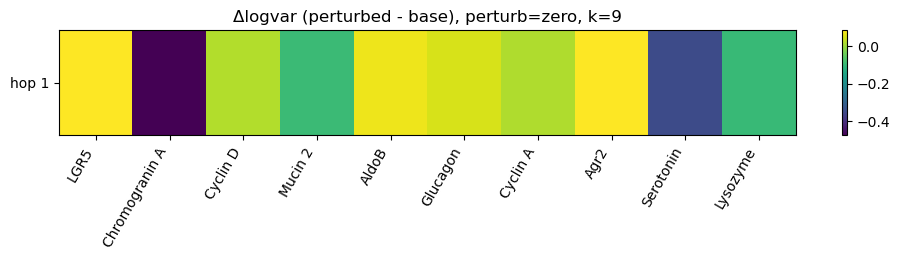

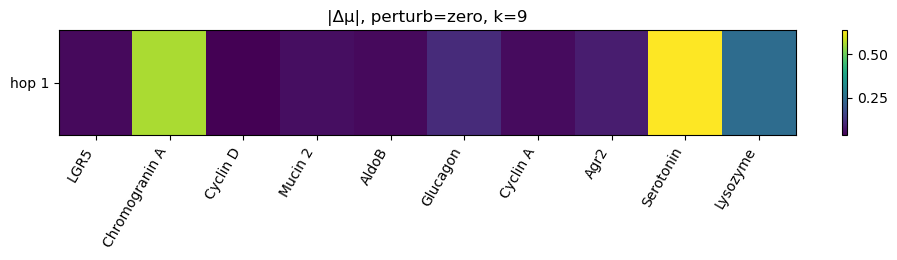

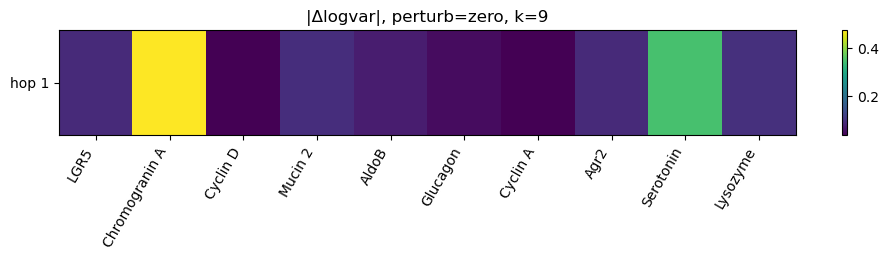

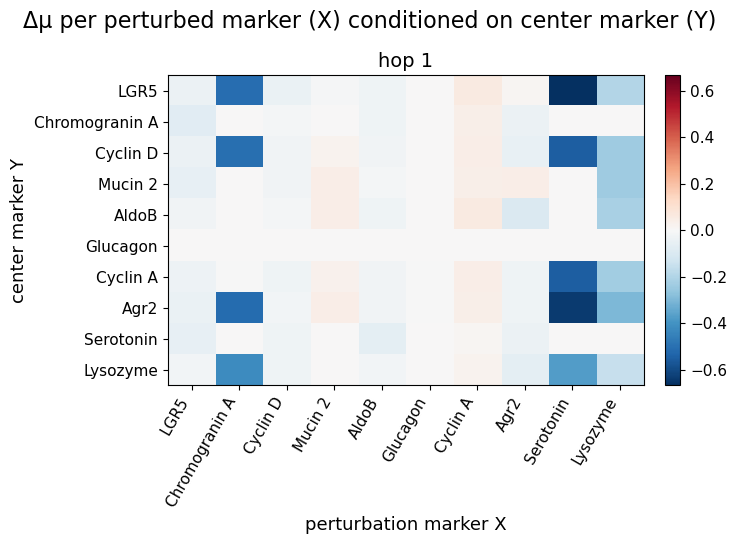

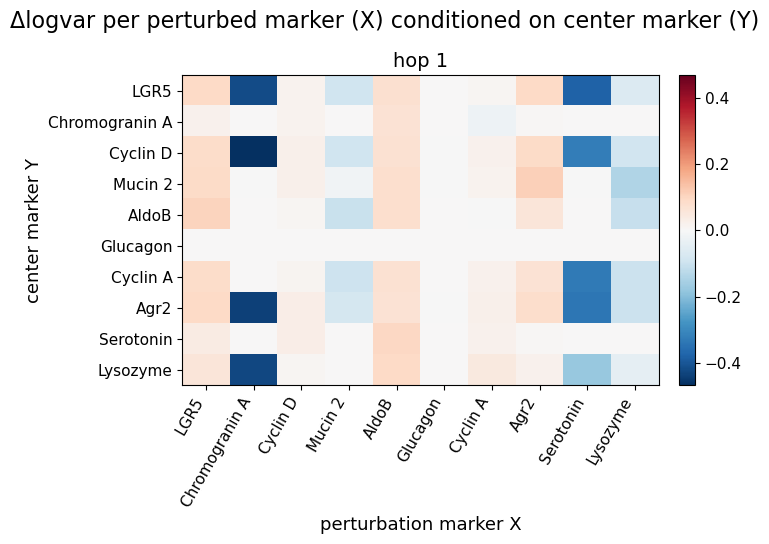

In [ ]:
# from perturbation_analysis import *


# TODO: make compatible with full organoid graph and not just ego subgraphs

num_hops   = num_layers
val_subgraphs  = build_ego_dataset(
    g_val,
    num_hops=num_hops,
    max_centers_per_graph=None,  # e.g. 80 random centers per organoid
    seed=0,
)


res = perturbation_influence_maps(
    subgraphs=val_subgraphs,
    model=model,
    marker_names=marker_names,
    k_hops=num_hops,
    perturb="zero",         # try "flip" too
    max_subgraphs=1000,      # start small (e.g. 100-500), then scale up
    batch_size=128,
)

# Mean shifts (directional effect)
plot_influence_heatmap(res["delta_mu_total"], res["hops"], res["marker_names"],
                       title=f"Δμ (perturbed - base), perturb=zero, k={k}")

plot_influence_heatmap(res["delta_lv_total"], res["hops"], res["marker_names"],
                       title=f"Δlogvar (perturbed - base), perturb=zero, k={k}")

# Magnitude-only (how strong the dependence is)
plot_influence_heatmap(res["delta_mu_abs_total"], res["hops"], res["marker_names"],
                       title=f"|Δμ|, perturb=zero, k={k}")

plot_influence_heatmap(res["delta_lv_abs_total"], res["hops"], res["marker_names"],
                       title=f"|Δlogvar|, perturb=zero, k={k}")


plot_influence_center_resolved(
    res["delta_mu_cmarker"], res["hops"], res["marker_names"],
    title="Δμ per perturbed marker (X) conditioned on center marker (Y)",
    sort_center=False, center_zero=True, cmap='RdBu_r'
)

plot_influence_center_resolved(
    res["delta_lv_cmarker"], res["hops"], res["marker_names"],
    title="Δlogvar per perturbed marker (X) conditioned on center marker (Y)",
    sort_center=False, center_zero=True, cmap='RdBu_r'
)


In [ ]:
from neighborhood_interpretation import *

# Example choices:
mode = "presence"   # or "presence"
hops = 3            # up to k

X_center, X_neigh = neighborhood_composition(
    g_val,
    hops=hops,
    mode=mode,
    include_center=False,
)

influence = sparse_neighborhood_influence_improvement(
    y_true=y,
    y_pred_mu=mu,
    X_center=X_center,
    X_neigh=X_neigh,
    marker_names=marker_names,
    alpha=1e-3,              # sparsity knob (try 1e-4, 1e-3, 1e-2)
    use_squared_error=True,  # improvement in squared error
)

# Example: print top neighbor markers for each center marker
for A, name in enumerate(marker_names):
    top = influence[A]["top"]
    if top:
        print(f"\nCenter {name}+: top neighborhood influences on improvement")
        for nb_name, coef in top:
            print(f"  {nb_name:>12s}  coef={coef:+.4f}")


Center Chromogranin A+: top neighborhood influences on improvement
      Glucagon  coef=-0.0043
       Mucin 2  coef=-0.0022
      Lysozyme  coef=-0.0020
         AldoB  coef=+0.0019
      Cyclin A  coef=+0.0015
  Chromogranin A  coef=+0.0010
      Cyclin D  coef=-0.0006
          LGR5  coef=+0.0001

Center Mucin 2+: top neighborhood influences on improvement
      Lysozyme  coef=+0.0008
          LGR5  coef=-0.0008
      Cyclin D  coef=-0.0000

Center Agr2+: top neighborhood influences on improvement
         AldoB  coef=+0.0003

Center Serotonin+: top neighborhood influences on improvement
         AldoB  coef=+0.0029
  Chromogranin A  coef=+0.0028
          Agr2  coef=+0.0014
      Cyclin D  coef=+0.0007
      Lysozyme  coef=+0.0005
       Mucin 2  coef=-0.0005
          LGR5  coef=+0.0002


In [ ]:
unc_inf = sparse_neighborhood_influence_uncertainty_reduction(
    y_true=y,
    X_center=X_center,
    X_neigh=X_neigh,
    pred_var=var,
    marker_names=marker_names,
    alpha=1e-3,
)

for A, name in enumerate(marker_names):
    top = unc_inf[A]["top"]
    if top:
        print(f"\nCenter {name}+: top neighborhood influences on uncertainty reduction")
        for nb_name, coef in top:
            print(f"  {nb_name:>12s}  coef={coef:+.4f}")



Center LGR5+: top neighborhood influences on uncertainty reduction
  Chromogranin A  coef=-0.0005
     Serotonin  coef=-0.0004

Center Chromogranin A+: top neighborhood influences on uncertainty reduction
     Serotonin  coef=-0.0095
       Mucin 2  coef=+0.0057
          Agr2  coef=-0.0055
  Chromogranin A  coef=-0.0039
      Glucagon  coef=+0.0014
      Lysozyme  coef=+0.0010
      Cyclin A  coef=-0.0009
      Cyclin D  coef=-0.0007
          LGR5  coef=-0.0007

Center Cyclin D+: top neighborhood influences on uncertainty reduction
  Chromogranin A  coef=-0.0002
     Serotonin  coef=-0.0001

Center Mucin 2+: top neighborhood influences on uncertainty reduction
      Lysozyme  coef=-0.0003

Center Agr2+: top neighborhood influences on uncertainty reduction
      Lysozyme  coef=-0.0001

Center Serotonin+: top neighborhood influences on uncertainty reduction
  Chromogranin A  coef=-0.0081
       Mucin 2  coef=+0.0049
     Serotonin  coef=-0.0034
          Agr2  coef=-0.0032
         Al